## Bulk functional analysis for Control = 10mix and perturbation = 11mix

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)

### Import libraries

In [2]:
import decoupler as dc

# Only needed for visualization:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
#import scanpy_helpers as sh
import seaborn as sns
from itertools import zip_longest
from anndata import AnnData
from matplotlib import collections  as mc

### Log TPM

In [3]:
# Log TPM
tpm = "/data/projects/2021/MicrobialMetabolites/bacterial-supernatant/10_rnaseq_pipeline/star_salmon/salmon.merged.gene_tpm.tsv"

tpm = pd.read_csv(tpm, sep="\t")

In [4]:
tpm

,gene_id,gene_name,mHCO3_10mix,mHCO3_11mix,mHCO3_ctrl,mHCO4_10mix,mHCO4_11mix,mHCO4_ctrl,mHCO5_10mix,mHCO5_11mix,mHCO5_ctrl,mHCO6_10mix,mHCO6_11mix,mHCO6_ctrl,mHCO7_10mix,mHCO7_11mix,mHCO7_ctrl,mHCO8_10mix,mHCO8_11mix,mHCO8_ctrl
0,ENSMUSG00000000001.5,Gnai3,32.373041,37.384390,32.373041,35.661660,46.371973,38.169797,37.908312,71.220471,48.530228,99.322202,58.695875,75.076888,50.372422,65.203292,53.272346,57.007018,89.545246,71.021326
1,ENSMUSG00000000003.16,Pbsn,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSMUSG00000000028.16,Cdc45,0.253707,0.384086,0.253707,0.622006,0.291910,0.041354,0.169802,0.048383,0.083100,0.091481,0.358047,0.320414,0.141156,0.043382,0.468362,0.060485,0.191787,0.232603
3,ENSMUSG00000000031.17,H19,0.000000,0.000000,0.000000,0.155501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.143219,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,ENSMUSG00000000037.18,Scml2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.042451,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55411,ENSMUSG00002076988.1,5S_rRNA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
55412,ENSMUSG00002076989.1,U1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
55413,ENSMUSG00002076990.1,ENSMUSG00002076990,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
55414,ENSMUSG00002076991.1,7SK,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
# Log TPM
deg = "/data/projects/2021/MicrobialMetabolites/bacterial-supernatant/20_deseq2icbi/paired_grp/deseq2_11mix_vs_10mix/11mix_10mix_IHWallGenes.tsv"
deg = pd.read_csv(deg, sep="\t")



In [6]:
deg

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,weight,gene_name,genes_description,gene_type
0,ENSMUSG00000029380,85.134297,2.521943,0.403477,6.250517,4.090967e-10,0.000006,0.720150,Cxcl1,chemokine (C-X-C motif) ligand 1,protein_coding
1,ENSMUSG00000029371,579.648559,1.818758,0.299308,6.076551,1.227951e-09,0.000009,0.662011,Cxcl5,chemokine (C-X-C motif) ligand 5,protein_coding
2,ENSMUSG00000037411,616.433710,2.300829,0.380521,6.046529,1.479992e-09,0.000006,2.073552,Serpine1,"serine (or cysteine) peptidase inhibitor, clad...",protein_coding
3,ENSMUSG00000029672,2517.818565,0.625780,0.105101,5.954088,2.615255e-09,0.000006,3.000000,Fam3c,FAM3 metabolism regulating signaling molecule C,protein_coding
4,ENSMUSG00000026811,2593.827269,-1.206002,0.216184,-5.578587,2.424797e-08,0.000034,2.726486,St6galnac6,"ST6 (alpha-N-acetyl-neuraminyl-2,3-beta-galact...",protein_coding
...,...,...,...,...,...,...,...,...,...,...,...
19042,ENSMUSG00000049761,0.588310,-0.000472,3.051139,-0.000155,9.998767e-01,1.000000,0.000000,Pmis2,PMIS2 transmembrane protein,protein_coding
19043,ENSMUSG00000060808,0.588310,-0.000472,3.051139,-0.000155,9.998767e-01,1.000000,0.000000,B9d1os,NaN,lncRNA
19044,ENSMUSG00000102550,2.628602,0.000174,1.158266,0.000150,9.998804e-01,1.000000,0.000000,Gm8276,"poly(A) binding protein, cytoplasmic 1 pseudogene",processed_pseudogene
19045,ENSMUSG00000105179,0.945309,-0.000418,3.046062,-0.000137,9.998904e-01,1.000000,0.000000,Gm42866,NaN,TEC


In [7]:
deg = deg[deg["padj"]<0.5]

In [8]:
deg.sort_values("padj").head(300)

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,weight,gene_name,genes_description,gene_type
0,ENSMUSG00000029380,85.134297,2.521943,0.403477,6.250517,4.090967e-10,0.000006,0.720150,Cxcl1,chemokine (C-X-C motif) ligand 1,protein_coding
2,ENSMUSG00000037411,616.433710,2.300829,0.380521,6.046529,1.479992e-09,0.000006,2.073552,Serpine1,"serine (or cysteine) peptidase inhibitor, clad...",protein_coding
3,ENSMUSG00000029672,2517.818565,0.625780,0.105101,5.954088,2.615255e-09,0.000006,3.000000,Fam3c,FAM3 metabolism regulating signaling molecule C,protein_coding
1,ENSMUSG00000029371,579.648559,1.818758,0.299308,6.076551,1.227951e-09,0.000009,0.662011,Cxcl5,chemokine (C-X-C motif) ligand 5,protein_coding
4,ENSMUSG00000026811,2593.827269,-1.206002,0.216184,-5.578587,2.424797e-08,0.000034,2.726486,St6galnac6,"ST6 (alpha-N-acetyl-neuraminyl-2,3-beta-galact...",protein_coding
5,ENSMUSG00000019997,1523.481851,1.593244,0.300975,5.293615,1.199220e-07,0.000127,3.000000,Ccn2,cellular communication network factor 2,protein_coding
6,ENSMUSG00000033735,2422.611717,-0.720278,0.137230,-5.248694,1.531810e-07,0.000139,3.000000,Spr,sepiapterin reductase,protein_coding
8,ENSMUSG00000018287,4200.420363,-0.583453,0.118368,-4.929134,8.259512e-07,0.000655,3.000000,Spag7,sperm associated antigen 7,protein_coding
11,ENSMUSG00000019578,1761.013455,-0.622999,0.131196,-4.748611,2.048188e-06,0.001192,2.726486,Ubxn6,UBX domain protein 6,protein_coding
10,ENSMUSG00000048992,11231.874755,-0.792544,0.165929,-4.776404,1.784575e-06,0.001192,3.135422,Prss32,"protease, serine 32",protein_coding


In [14]:
gene_col = "gene_name"
genes = ["Cxcl1", "Cxcl2", "Cxcl5", "Tnf"]
sample_cols = [c for c in tpm.columns if c.startswith("mHCO") and "_" in c]
df = tpm[[gene_col] + sample_cols].copy()
df = df[df[gene_col].isin(genes)]

long = df.melt(
    id_vars=gene_col,
    value_vars=sample_cols,
    var_name="sample",
    value_name="log_tpm"
)

ValueError: Could not interpret value `condition` for `x`. An entry with this name does not appear in `data`.

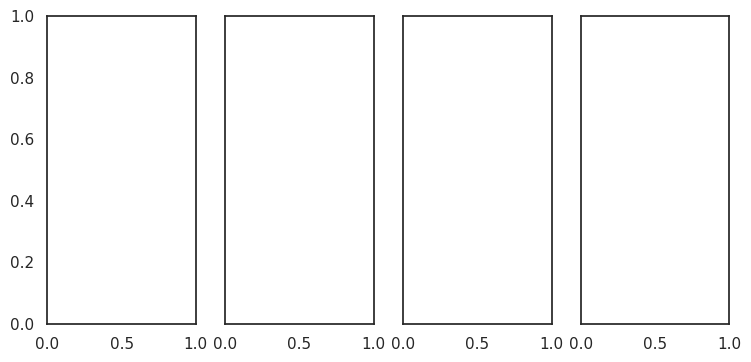

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
ymin = long["log_tpm"].min()
ymax = long["log_tpm"].max()

pad = 0.05 * (ymax - ymin)
ymin -= pad
ymax += pad

sns.set(style="white")

genes = ["Cxcl1", "Cxcl2", "Cxcl5", "Tnf"]
cond_order = ["10mix", "11mix"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(genes),
    figsize=(2.2 * len(genes), 4),
    sharey=True
)

for ax, g in zip(axes, genes):
    gdf = long[long[gene_col] == g].copy()

    # Boxplot
    sns.boxplot(
        data=gdf,
        x="condition",
        y="log_tpm",
        order=cond_order,
        showfliers=False,
        width=0.5,
        ax=ax,
        boxprops=dict(facecolor="none", edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black")
    )

    # Points colored by replicate
    sns.stripplot(
        data=gdf,
        x="condition",
        y="log_tpm",
        order=cond_order,
        hue="replicate",
        dodge=False,
        jitter=0.12,
        size=6,
        alpha=0.9,
        ax=ax
    )

    # Paired lines
    for rep, sub in gdf.groupby("replicate"):
        sub = sub.sort_values("condition")
        if sub["condition"].nunique() == 2:
            ax.plot(
                [0, 1],
                sub["log_tpm"].values,
                linewidth=1,
                alpha=0.6,
                zorder=0
            )

    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylim(ymin, ymax)

    # Only keep y-label on first plot
    if ax != axes[0]:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("log(TPM)")

# Remove duplicate legends
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Replicate",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

for ax in axes:
    ax.legend_.remove()

plt.tight_layout()
#out_svg = "paired_boxplots_chemokines.svg"

plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight"
)
plt.show()


Paired Wilcoxon stats (computed on log_tpm):
    gene  wilcoxon_stat  p_value  n_pairs   p_adj
0  Cxcl1            0.0  0.03125        6  0.0625
1  Cxcl2            1.0  0.06250        6  0.0625
2  Cxcl5            1.0  0.06250        6  0.0625
3    Tnf            0.0  0.03125        6  0.0625


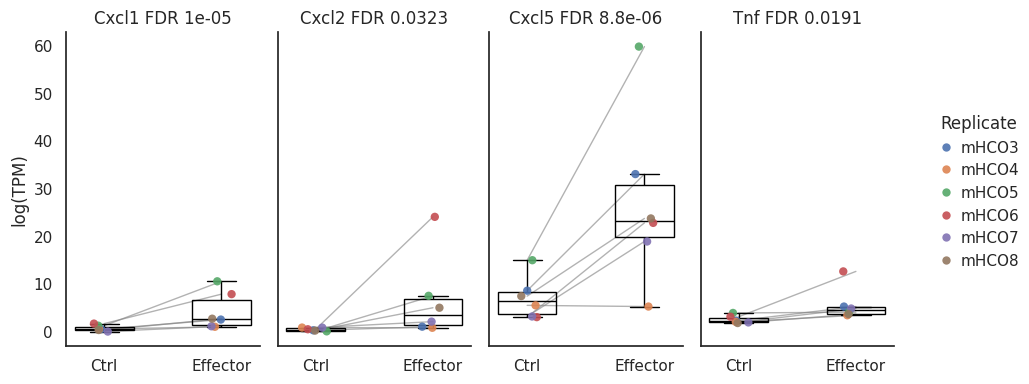

Saved: paired_boxplots_Ctrl_vs_Effector_customFDRtitles.svg


In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# -----------------------------
# 1) Load data
# -----------------------------
tpm_path = "/data/projects/2021/MicrobialMetabolites/bacterial-supernatant/10_rnaseq_pipeline/star_salmon/salmon.merged.gene_tpm.tsv"
deg_path = "/data/projects/2021/MicrobialMetabolites/bacterial-supernatant/20_deseq2icbi/paired_grp/deseq2_11mix_vs_10mix/11mix_10mix_IHWallGenes.tsv"

tpm = pd.read_csv(tpm_path, sep="\t")
deg = pd.read_csv(deg_path, sep="\t")  # loaded as requested (not required for plotting below)

# -----------------------------
# 2) Settings
# -----------------------------
genes = ["Cxcl1", "Cxcl2", "Cxcl5", "Tnf"]

# IMPORTANT: set this to the gene column name in your TPM file
gene_col = "gene_name"  # change if needed (e.g. "gene_name", "Gene", "external_gene_name")

# Compare these conditions (paired by replicate)
cond_order = ["10mix", "11mix"]
cond_label_map = {"10mix": "Ctrl", "11mix": "Effector"}

# Gene panel titles you want (custom FDR text)
gene_title_map = {
    "Cxcl1": "Cxcl1 FDR 1e-05",
    "Cxcl2": "Cxcl2 FDR 0.0323",
    "Cxcl5": "Cxcl5 FDR 8.8e-06",
    "Tnf":   "Tnf FDR 0.0191",
}

# Output
out_svg = "paired_boxplots_Ctrl_vs_Effector_customFDRtitles.svg"

# -----------------------------
# 3) Build long dataframe
# -----------------------------
# Detect sample columns like mHCO3_10mix, mHCO3_11mix
sample_cols = [c for c in tpm.columns if c.startswith("mHCO") and "_" in c]

df = tpm[[gene_col] + sample_cols].copy()
df = df[df[gene_col].isin(genes)].copy()

long = df.melt(
    id_vars=gene_col,
    value_vars=sample_cols,
    var_name="sample",
    value_name="log_tpm"
)

# Parse replicate + condition from "mHCO3_10mix"
long[["replicate", "condition"]] = long["sample"].str.rsplit("_", n=1, expand=True)

# Keep only the two conditions we compare
long = long[long["condition"].isin(cond_order)].copy()

# Keep only true pairs (replicate has both conditions) per gene
paired_counts = (
    long.groupby([gene_col, "replicate"])["condition"]
        .nunique()
        .reset_index(name="n_cond")
)
paired_reps = paired_counts.loc[paired_counts["n_cond"] == len(cond_order), [gene_col, "replicate"]]
long = long.merge(paired_reps, on=[gene_col, "replicate"], how="inner")

# Order conditions and create display labels
long["condition"] = pd.Categorical(long["condition"], categories=cond_order, ordered=True)
long["condition_label"] = long["condition"].map(cond_label_map)

# -----------------------------
# 4) Stats: paired Wilcoxon per gene + FDR
#     (kept for completeness; titles use YOUR provided FDR strings)
# -----------------------------
stats = []
for g in genes:
    gdf = long[long[gene_col] == g].copy()
    wide = gdf.pivot(index="replicate", columns="condition", values="log_tpm")
    wide = wide[cond_order].dropna()

    stat, pval = wilcoxon(wide[cond_order[0]], wide[cond_order[1]])
    stats.append({"gene": g, "wilcoxon_stat": stat, "p_value": pval, "n_pairs": wide.shape[0]})

stats_df = pd.DataFrame(stats)
stats_df["p_adj"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
print("Paired Wilcoxon stats (computed on log_tpm):")
print(stats_df.sort_values("p_adj"))

# -----------------------------
# 5) Global y-scale (shared)
# -----------------------------
ymin = long["log_tpm"].min()
ymax = long["log_tpm"].max()
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
ymin -= pad
ymax += pad

# -----------------------------
# 6) Plot: one row, no grid, outline-only boxes, paired lines
# -----------------------------
sns.set_style("white")          # no grid
plt.rcParams["svg.fonttype"] = "none"  # keep text editable in SVG

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(genes),
    figsize=(2.3 * len(genes), 4),
    sharey=True
)

if len(genes) == 1:
    axes = [axes]

x_tick_labels = [cond_label_map[c] for c in cond_order]  # ["Ctrl", "Effector"]

for ax, g in zip(axes, genes):
    gdf = long[long[gene_col] == g].copy()

    # Boxplot (outline only)
    sns.boxplot(
        data=gdf,
        x="condition_label",
        y="log_tpm",
        order=x_tick_labels,
        showfliers=False,
        width=0.5,
        ax=ax,
        boxprops=dict(facecolor="none", edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black")
    )

    # Points colored by replicate
    sns.stripplot(
        data=gdf,
        x="condition_label",
        y="log_tpm",
        order=x_tick_labels,
        hue="replicate",
        dodge=False,
        jitter=0.12,
        size=6,
        alpha=0.9,
        ax=ax
    )

    # Paired lines (replicate) Ctrl -> Effector
    for rep, sub in gdf.groupby("replicate"):
        sub = sub.copy()
        sub["condition_label"] = pd.Categorical(sub["condition_label"], categories=x_tick_labels, ordered=True)
        sub = sub.sort_values("condition_label")
        if sub["condition_label"].nunique() == 2:
            ax.plot(
                [0, 1],
                sub["log_tpm"].values,
                linewidth=1,
                alpha=0.6,
                color="gray",
                zorder=0
            )

    # Titles: use YOUR provided labels (not computed)
    ax.set_title(gene_title_map.get(g, g))
    ax.set_xlabel("")
    ax.set_ylim(ymin, ymax)

    # Clean spines
    sns.despine(ax=ax)

    # Only first panel gets y label
    if ax != axes[0]:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("log(TPM)")

    # Remove per-axis legend (global legend below)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Replicate",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.savefig(out_svg, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved: {out_svg}")


In [10]:
array = ["ENSMUSG00000029371.8",#Cxcl5
"ENSMUSG00000026822.15",
"ENSMUSG00000029380.12",#Cxcl1
"ENSMUSG00000031775.6",
"ENSMUSG00000056293.13",
"ENSMUSG00000058427.11", #Cxcl2
"ENSMUSG00000021403.4",
"ENSMUSG00000000627.16",
"ENSMUSG00000018554.14",
"ENSMUSG00000018774.14",
"ENSMUSG00000055748.13",
"ENSMUSG00000026463.18",
"ENSMUSG00000026811.19",
"ENSMUSG00000048992.10",
"ENSMUSG00000028039.12",
"ENSMUSG00000033735.10",
"ENSMUSG00000090264.2",
"ENSMUSG00000106300.2",
"ENSMUSG00000037033.10",
"ENSMUSG00000004665.11",
"ENSMUSG00000026822.15", #Lcn2
"ENSMUSG00000024401.15", #Tnf
"ENSMUSG00000026166.15"] #Ccl20

In [11]:
array[22]

'ENSMUSG00000026166.15'

/tmp/ipykernel_61229/4212573755.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tpm_1["sample"][i]= tpm_1["sample_conditions"][i][0]
/tmp/ipykernel_61229/4212573755.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tpm_1["condition"][i]= tpm_1["sample_conditions"][i][1]


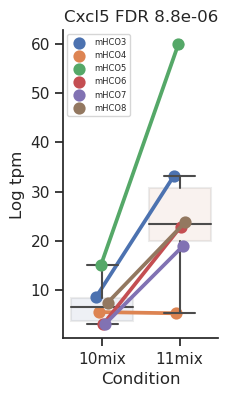

In [14]:


tpm_1 = tpm[tpm["gene_id"]==array[0]]
tpm_1 = tpm_1.iloc[:,2:]
tpm_1 = tpm_1.T
tpm_1 = tpm_1.reset_index()
tpm_1["sample_conditions"]= tpm_1["index"].str.split("_", n = 1, expand = False)
tpm_1["sample"] = 0 
tpm_1["condition"] = 0 
for i in range(len(tpm_1)):
    tpm_1["sample"][i]= tpm_1["sample_conditions"][i][0]
    tpm_1["condition"][i]= tpm_1["sample_conditions"][i][1]
    
tpm_1 = tpm_1.drop("sample_conditions", axis = 1)
tpm_1 = tpm_1.drop("index", axis = 1)
tpm_1 = tpm_1[tpm_1["condition"].str.contains("ctrl") == False]
#tpm_1 = tpm_1[tpm_1["sample"].str.contains("mHCO4") == False]

sns.set(rc={'figure.figsize':(2,4)})
sns.set(font_scale=0.9)
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
#sns.set_style("whitegrid")
sns.set_theme(style="ticks", rc=custom_params)

plt.title(str(deg.iloc[1]["gene_name"]) + " FDR " + str(round(deg.iloc[1]["padj"],7)))
sns.pointplot(data=tpm_1, x="condition", y=tpm_1.columns[0], hue = "sample",dodge=True, scale = 1)
sns.boxplot(data=tpm_1, x="condition",  y=tpm_1.columns[0], dodge=True, boxprops=dict(alpha=.1))
#define seaborn background colors

plt.xlabel("Condition")
plt.ylabel("Log tpm")
plt.legend(fontsize='6')


plt.savefig('output.png', dpi=500, bbox_inches='tight')




In [ ]:


tpm_1 = tpm[tpm["gene_id"]==array[2]]
tpm_1 = tpm_1.iloc[:,2:]
tpm_1 = tpm_1.T
tpm_1 = tpm_1.reset_index()
tpm_1["sample_conditions"]= tpm_1["index"].str.split("_", n = 1, expand = False)
tpm_1["sample"] = 0 
tpm_1["condition"] = 0 
for i in range(len(tpm_1)):
    tpm_1["sample"][i]= tpm_1["sample_conditions"][i][0]
    tpm_1["condition"][i]= tpm_1["sample_conditions"][i][1]
    
tpm_1 = tpm_1.drop("sample_conditions", axis = 1)
tpm_1 = tpm_1.drop("index", axis = 1)
tpm_1 = tpm_1[tpm_1["condition"].str.contains("ctrl") == False]
#tpm_1 = tpm_1[tpm_1["sample"].str.contains("mHCO4") == False]

sns.set(rc={'figure.figsize':(2,4)})
sns.set(font_scale=0.9)
#custom_params = {"axes.spines.right": False, "axes.spines.top": False}
#sns.set_style("whitegrid")
sns.set_theme(style="ticks", rc=custom_params)

plt.title(str(deg.iloc[0]["gene_name"]) + " FDR " + str(round(deg.iloc[0]["padj"],5)))
sns.pointplot(data=tpm_1, x="condition", y=tpm_1.columns[0], hue = "sample",dodge=True, scale = 1)
sns.boxplot(data=tpm_1, x="condition",  y=tpm_1.columns[0], dodge=True, boxprops=dict(alpha=.1))
#define seaborn background colors

plt.xlabel("Condition")
plt.ylabel("Log tpm")
plt.legend(fontsize='6')


plt.savefig('output.png', dpi=500, bbox_inches='tight')




In [ ]:


tpm_1 = tpm[tpm["gene_id"]==array[20]]
tpm_1 = tpm_1.iloc[:,2:]
tpm_1 = tpm_1.T
tpm_1 = tpm_1.reset_index()
tpm_1["sample_conditions"]= tpm_1["index"].str.split("_", n = 1, expand = False)
tpm_1["sample"] = 0 
tpm_1["condition"] = 0 
for i in range(len(tpm_1)):
    tpm_1["sample"][i]= tpm_1["sample_conditions"][i][0]
    tpm_1["condition"][i]= tpm_1["sample_conditions"][i][1]
    
tpm_1 = tpm_1.drop("sample_conditions", axis = 1)
tpm_1 = tpm_1.drop("index", axis = 1)
tpm_1 = tpm_1[tpm_1["condition"].str.contains("ctrl") == False]
#tpm_1 = tpm_1[tpm_1["sample"].str.contains("mHCO4") == False]

sns.set(rc={'figure.figsize':(2,4)})
sns.set(font_scale=0.9)
#custom_params = {"axes.spines.right": False, "axes.spines.top": False}
#sns.set_style("whitegrid")
sns.set_theme(style="ticks", rc=custom_params)

plt.title(str(deg.iloc[131]["gene_name"]) + " FDR " + str(round(deg.iloc[131]["padj"],4)))
sns.pointplot(data=tpm_1, x="condition", y=tpm_1.columns[0], hue = "sample",dodge=True, scale = 1)
sns.boxplot(data=tpm_1, x="condition",  y=tpm_1.columns[0], dodge=True, boxprops=dict(alpha=.1))
#define seaborn background colors

plt.xlabel("Condition")
plt.ylabel("Log tpm")
plt.legend(fontsize='6')


plt.savefig('output.png', dpi=500, bbox_inches='tight')




In [ ]:


tpm_1 = tpm[tpm["gene_id"]==array[21]]
tpm_1 = tpm_1.iloc[:,2:]
tpm_1 = tpm_1.T
tpm_1 = tpm_1.reset_index()
tpm_1["sample_conditions"]= tpm_1["index"].str.split("_", n = 1, expand = False)
tpm_1["sample"] = 0 
tpm_1["condition"] = 0 
for i in range(len(tpm_1)):
    tpm_1["sample"][i]= tpm_1["sample_conditions"][i][0]
    tpm_1["condition"][i]= tpm_1["sample_conditions"][i][1]
    
tpm_1 = tpm_1.drop("sample_conditions", axis = 1)
tpm_1 = tpm_1.drop("index", axis = 1)
tpm_1 = tpm_1[tpm_1["condition"].str.contains("ctrl") == False]
#tpm_1 = tpm_1[tpm_1["sample"].str.contains("mHCO4") == False]

sns.set(rc={'figure.figsize':(2,4)})
sns.set(font_scale=0.9)
#custom_params = {"axes.spines.right": False, "axes.spines.top": False}
#sns.set_style("whitegrid")
sns.set_theme(style="ticks", rc=custom_params)

plt.title(str(deg.iloc[70]["gene_name"]) + " FDR " + str(round(deg.iloc[70]["padj"],4)))
sns.pointplot(data=tpm_1, x="condition", y=tpm_1.columns[0], hue = "sample",dodge=True, scale = 1)
sns.boxplot(data=tpm_1, x="condition",  y=tpm_1.columns[0], dodge=True, boxprops=dict(alpha=.1))
#define seaborn background colors

plt.xlabel("Condition")
plt.ylabel("Log tpm")
plt.legend(fontsize='6')


plt.savefig('output.png', dpi=500, bbox_inches='tight')




In [ ]:


tpm_1 = tpm[tpm["gene_id"]==array[22]]
tpm_1 = tpm_1.iloc[:,2:]
tpm_1 = tpm_1.T
tpm_1 = tpm_1.reset_index()
tpm_1["sample_conditions"]= tpm_1["index"].str.split("_", n = 1, expand = False)
tpm_1["sample"] = 0 
tpm_1["condition"] = 0 
for i in range(len(tpm_1)):
    tpm_1["sample"][i]= tpm_1["sample_conditions"][i][0]
    tpm_1["condition"][i]= tpm_1["sample_conditions"][i][1]
    
tpm_1 = tpm_1.drop("sample_conditions", axis = 1)
tpm_1 = tpm_1.drop("index", axis = 1)
tpm_1 = tpm_1[tpm_1["condition"].str.contains("ctrl") == False]
#tpm_1 = tpm_1[tpm_1["sample"].str.contains("mHCO4") == False]

sns.set(rc={'figure.figsize':(2,4)})
sns.set(font_scale=0.9)
#custom_params = {"axes.spines.right": False, "axes.spines.top": False}
#sns.set_style("whitegrid")
sns.set_theme(style="ticks", rc=custom_params)

plt.title(str(deg.iloc[61]["gene_name"]) + " FDR " + str(round(deg.iloc[61]["padj"],4)))
sns.pointplot(data=tpm_1, x="condition", y=tpm_1.columns[0], hue = "sample",dodge=True, scale = 1)
sns.boxplot(data=tpm_1, x="condition",  y=tpm_1.columns[0], dodge=True, boxprops=dict(alpha=.1))
#define seaborn background colors

plt.xlabel("Condition")
plt.ylabel("Log tpm")
plt.legend(fontsize='6')


plt.savefig('output.png', dpi=500, bbox_inches='tight')


